<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi

</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 6</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 7</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 07_01_A**
- Aufgabe 07_01_B
- Aufgabe 07_02

## Aufgabe 1 Teil A) Numerov-Integration und Shooting Algorithmus

---

In der Vorlesung wurde die Numerov-Integration in Kombination mit der Shooting Methode eingeführt, um Differentialgleichungen der Form

$$
    \partial_x^2\psi(x) = \kappa(x) \psi(x) \\
    \psi(x_{min}) = \psi_A \\
    \psi(x_{max}) = \psi_B
$$

zu lösen.

Die `Numerov-Integration` dieses Problems ist dabei durch die Vorschrift
$$
    \psi(x_n + \epsilon) = \left\lbrace 2 \left(1 - \frac{5 \epsilon^2}{12} \kappa(x_n) \right) \psi(x_n)
                         - \left(1 + \frac{\epsilon^2}{12} \kappa(x_n - \epsilon)\right) \psi(x_n-\epsilon) \right\rbrace
                           \frac{1}{1 + \epsilon^2/12 \kappa(x_n + \epsilon)}
$$
definiert, wobei  $x_n = x_{min} + \epsilon(n-1)$ gilt mit $n$ von $1$ bis $N$. Die $x_n$ definieren dabei die Diskretisierung des Raumes und mit $\psi_n := \psi(x_n)$ bezeichnen wir im Folgenden die Diskretisierung
der Lösung.

Da es sich um eine Differentialgleichung zweiter Ordnung handelt, braucht man auch zwei Anfangsbedingungen, um den Algorithmus zu vervollständigen:

$$
    \psi_1 = \psi(x_{min}) = \psi_A \\
    \psi_2 = \psi(x_{min} + \epsilon) = c_1
$$

Dabei ist $\psi_0$ durch das ursprüngliche Problem vorgegeben und $c_1$ muss eventuell angepasst werden, um die zweite Randbedingung $\psi_N = \psi(x_{max}) = \psi_B$ zu erfüllen. 
Um das zu erreichen, wurde in der Vorlesung der `Shooting Algorithmus` eingefuehrt.

---

> **Aufgabe**:
> - Was ist die Fehlerabschätzung der Numerov-Integration?
> - Beschreiben Sie kurz das Vorgehen bei dem Shooting Algorithmus

---

### Fehlerabschätzung der Numerov-Integration

Die Numerov-Methode ist ein Verfahren zur numerischen Integration von Differentialgleichungen der Form $\partial_x^2 \psi = \kappa(x)\psi$. Sie ist von **4. Ordnung** in der Schrittweite $\epsilon$, d.h. der lokale Fehler pro Schritt ist $\mathcal{O}(\epsilon^6)$ und der **globale Fehler** ist:

$$\text{Fehler} = \mathcal{O}(\epsilon^4)$$

Das bedeutet: halbiert man die Schrittweite $\epsilon$, so verringert sich der Fehler um den Faktor $2^4 = 16$.

---

### Vorgehen beim Shooting-Algorithmus

Der Shooting-Algorithmus löst Randwertprobleme durch Rückführung auf ein Anfangswertproblem:

1. **Linke Randbedingung setzen**: Man setzt $\psi_1 = \psi_A = 0$ (bekannt) und wählt einen freien Parameter – hier die Energie $E$.

2. **Integration**: Mit dem Numerov-Algorithmus integriert man die SSG vom linken Rand $x_{\min}$ zum rechten Rand $x_{\max}$, wobei $\psi_2 = c_1 = 1$ als zweiter Startwert gewählt wird (die Normierung wird hinterher angepasst).

3. **Prüfung der rechten Randbedingung**: Man überprüft, ob $\psi_N = \psi(x_{\max}) \approx 0$ gilt.

4. **Nullstellensuche in $E$**: Die Funktion $f(E) := \psi_N(E)$ wechselt ihr Vorzeichen, wenn $E$ durch einen Eigenwert läuft. Man sucht alle Nullstellen von $f(E)$ (z.B. mit Bisektionsverfahren auf Teilintervallen) – jede Nullstelle entspricht einem Eigenwert $E_n$ mit zugehöriger Eigenfunktion $\psi_n(x)$.

5. **Normierung**: Die gefundene Eigenfunktion wird auf $\int |\psi(x)|^2 \, dx = 1$ normiert.


### Stationäre Schrödingergleichung

Probleme der oben beschriebenen Form treten beim Lösen der stationären Schrödingergleichung (SSG) in einem beliebigen Potential auf. Dabei ist die SSG im Allgemeinen definiert als:

$$
     H \psi = E \psi \\
     H = \frac{p^2}{2m} + V(x) \\
     p = -i\partial_x
$$

wobei wir $\hbar = 1$ gesetzt haben. 
Diese Gleichung beschreibt das Verhalten eines quantenmechanischen Teilchens in einem Potential, beschrieben durch `V(x)`. 

Im Folgenden soll das Problem mithilfe des `Numerov + Shooting Algorithmus` gelöst werden, wobei für die Potentiale $V(x)$ verschiedene Potentialtöpfe benutzt werden sollen.
Dabei ist ein Potentialtopf im Allgemeinen definiert durch:

$$
     V(x) = \begin{cases}
               f(x)    &\text{für} \ x\in [x_{min}, x_{max}] := \mathcal{I}\\
               \infty  &\text{sonst}
            \end{cases}
$$
wobei $f(x)$ eine beliebige Funktion auf dem Intervall $\mathcal{I}$ ist.

Für diese Art von Potential kann gezeigt werden, dass die Wellenfunktion $\psi(x)$ außerhalb von $\mathcal{I}$ verschwinden muss:
$$
     \psi|_{\mathbb{R}\setminus\mathcal{I}}(x) \equiv 0
$$

wodurch man die folgenden Randbedingungen für die stationäre Schrödingergleichung bekommt:

$$
     \psi(x_{min}) = \psi(x_{max}) = 0 \, .
$$

Um die Anzahl der Parameter zu reduzieren, fixieren Sie im Folgenden die folgenden Werte:

- `x_min = -1` 
- `x_max = 1`
- `N = 1000`
- `ϵ = (x_min - x_max)/(N - 1)`
    
Da nun auch die Energie `E` ein freier unbekannter Parameter ist, besteht hier der Shooting-Algorithmus darin, dass man zu einem gegebenen $E$ die SSG integriert und dann überprüft, ob die Randbedingungen bei $x_{max}$ erfüllt werden.

Da die Randbedingungen bei $x_{max}$ $\psi_N = 0$ sind, ist es des Weiteren auch unwichtig, wie man den 2. Startwert $c_1$ wählt. Daher nehmen Sie im Folgenden die Startwerte:

$$
     \psi(-1) = 0 \\
     \psi(-0.998) = 1
$$

### a) Implementierung der Numerov-Integration

---

Schreiben Sie nun eine Funktion `numerov(f,E)`, welche zu einer gegebenen Funktion $f(x)$ und einer Energie $E$ mithilfe des Numerov-Algorithmus die SSG integriert und die Wellenfunktion zurückgibt.

Da man normalerweise in der Quantenmechanik fordert, dass

$$
     \int_\mathbb{R} \! \mathrm{d}x\, |\psi(x)|^2 = 1
$$

gilt, wollen wir, dass unsere Wellenfunktion dieselbe Normierung erfüllt.

In [11]:
function numerov(V, E; xmin = -1, xmax = 1, N = 1000)
    # Diskretisierung des Raumes
    x_range = range(xmin, xmax, length=N)
    ε = (xmax - xmin) / (N - 1)
    
    # κ(x) = 2m(V(x) - E) / ℏ²  mit m=1, ℏ=1  →  κ(x) = 2(V(x) - E)
    κ = -[2.0 * (V(x) - E) for x in x_range]
    
    # Wellenfunktion-Array
    ψ = zeros(Float64, N)
    
    # Anfangsbedingungen: ψ(x_min)=0, ψ(x_min+ε)=1
    ψ[1] = 0.0
    ψ[2] = 1.0
    
    # Numerov-Rekursion
    for n in 2:(N-1)
        num = 2.0 * (1.0 - (5.0 * ε^2 / 12.0) * κ[n]) * ψ[n] -
              (1.0 + (ε^2 / 12.0) * κ[n-1]) * ψ[n-1]
        den = 1.0 + (ε^2 / 12.0) * κ[n+1]
        ψ[n+1] = num / den
    end
    
    # Normierung: ∫|ψ(x)|² dx ≈ ε · Σ|ψ_n|²  = 1
    norm = sqrt(sum(abs2.(ψ)) * ε)
    ψ ./= norm
    
    return ψ, collect(x_range)
end


numerov (generic function with 1 method)

### b) Visualisierung

---

Tragen Sie die Endpunkte der Numerov-Wellenfunktion gegen verschiedene Energien für `V(x) = 0` auf. 

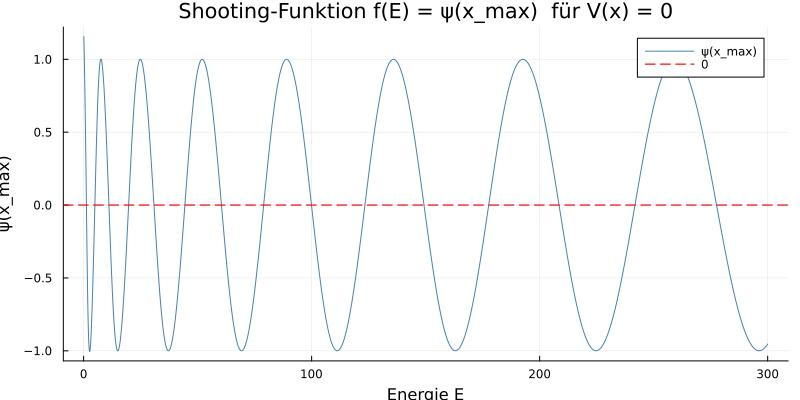

In [15]:
using Plots

V1(x) = 0   # wird hier vorab definiert, falls noch nicht geschehen

# Energiebereich: analytisch liegen die Eigenwerte bei E_n = n²π²/2
# für V=0 im Kasten [-1,1] der Breite L=2
E_values = range(0.1, 300.0, length=3000)

# Endpunkte ψ(x_max) als Funktion von E berechnen
endpoints = [numerov(V1, E)[1][end] for E in E_values]

plot(E_values, endpoints,
    xlabel = "Energie E",
    ylabel = "ψ(x_max)",
    title  = "Shooting-Funktion f(E) = ψ(x_max)  für V(x) = 0",
    label  = "ψ(x_max)",
    lw = 1.0,
    color  = :steelblue,
    size   = (800, 400))
hline!([0], color=:red, lw=1.2, ls=:dash, label="0")


### c) Implementierung und Ausführung des Shooting-Algorithmus

---

Um den Shooting-Algorithmus zu implementieren, brauchen Sie nun noch eine Funktion, welche die Nullstellen einer Funktion auf einem Intervall bestimmt.

Verwenden Sie hierfür eine Methode Ihrer Wahl. Beachten Sie jedoch, dass es auf dem Intervall mehrere Nullstellen geben kann und wir **alle** Nullstellen finden wollen. Dafür zerlegen Sie das Intervall am besten in kleine Portionen und suchen auf den kleinen Teilintervallen nach Nullstellen.

Bestimmen Sie dann die ersten 10 Wellenfunktionen + Energien für die 3 Potentiale `V1(x)`, `V2(x)` und `V3(x)` mithilfe der Numerov-Integration und des Shooting-Algorithmus.

In [16]:
V1(x) = 0
V2(x) = 50 * x

toepfe = [-0.6, -0.15, 0.15, 0.6]
function V3(x)
    for t in toepfe
        if abs(x-t) < 0.1
            return -120
        end
    end
    return 0
end

V3 (generic function with 1 method)

Berechne Eigenwerte …

Eigenwerte V1 (freier Kasten):
  E_1 = 1.2337   (analytisch: 4.9348)
  E_2 = 4.9348   (analytisch: 19.7392)
  E_3 = 11.1033   (analytisch: 44.4132)
  E_4 = 19.7392   (analytisch: 78.9568)
  E_5 = 30.8425   (analytisch: 123.3701)
  E_6 = 44.4132   (analytisch: 177.6529)
  E_7 = 60.4513   (analytisch: 241.8053)
  E_8 = 78.9568   (analytisch: 315.8273)
  E_9 = 99.9297   (analytisch: 399.719)
  E_10 = 123.3701   (analytisch: 493.4802)

Eigenwerte V2 (lineares Potential V=50x):
  E_1 = -24.8135
  E_2 = -5.9639
  E_3 = 9.4686
  E_4 = 23.1178
  E_5 = 35.7961
  E_6 = 48.8274
  E_7 = 63.8672
  E_8 = 81.588
  E_9 = 102.0074
  E_10 = 125.0515

Eigenwerte V3 (vier Potentialtöpfe):
  E_1 = -83.9024
  E_2 = -77.1427
  E_3 = -76.8082
  E_4 = -69.2563
  E_5 = 3.3288
  E_6 = 10.6482
  E_7 = 20.7716
  E_8 = 42.0054
  E_9 = 61.5413
  E_10 = 74.4604


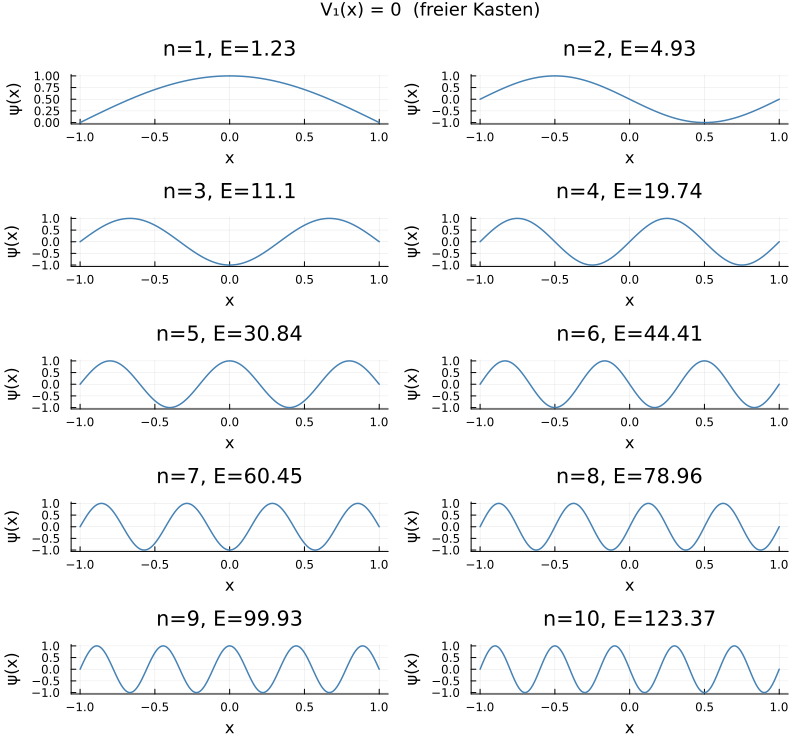

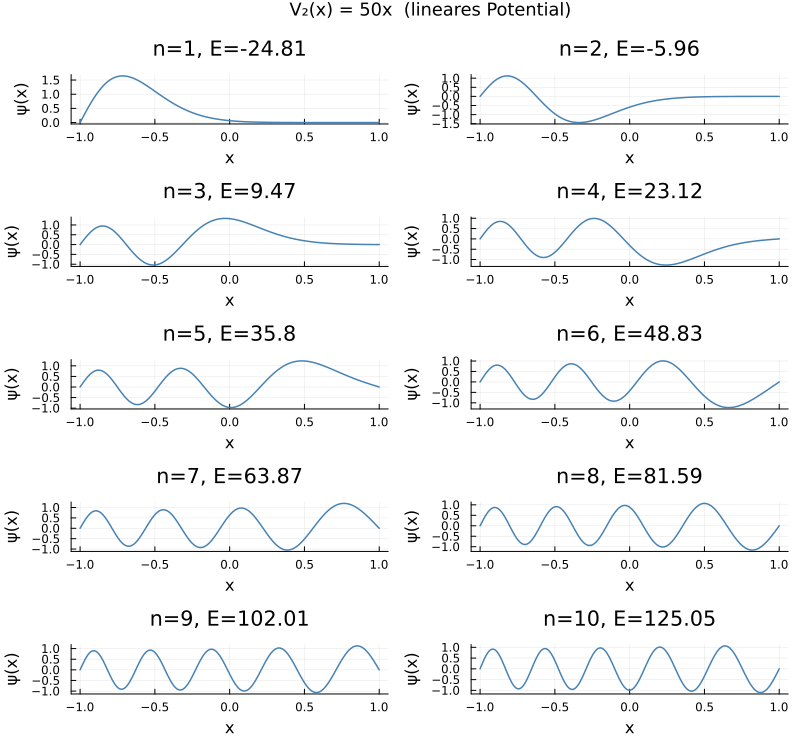

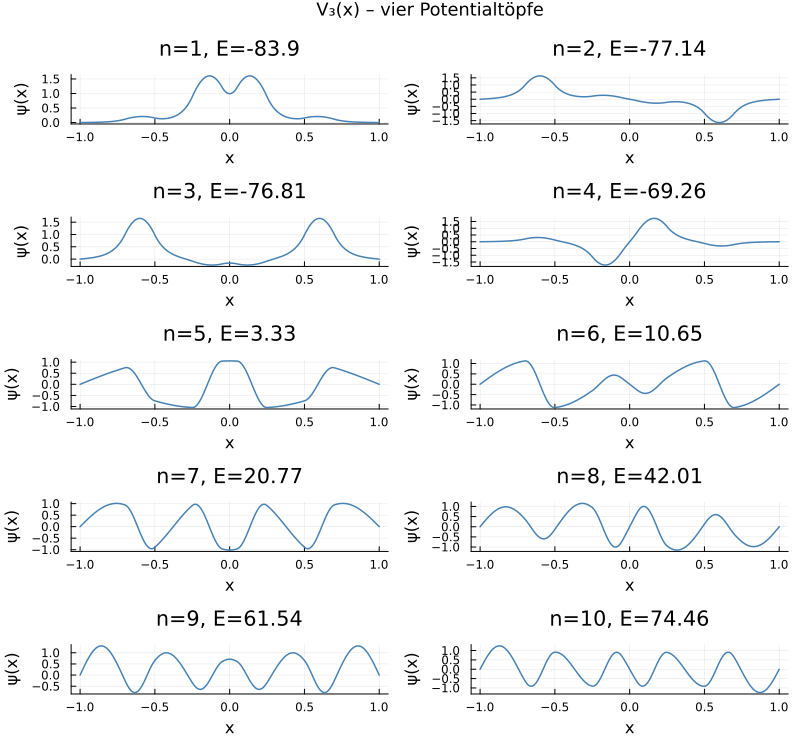

In [ ]:
# -------------------------------------------------------
# Shooting-Algorithmus: Nullstellensuche über Bisektions-
# methode auf kleinen Teilintervallen
# -------------------------------------------------------

function find_eigenvalues(V; E_min=0.1, E_max=300.0, n_scan=5000, n_eigen=10)
    E_scan    = range(E_min, E_max, length=n_scan)
    endpoints = [numerov(V, E)[1][end] for E in E_scan]
    
    eigenvalues = Float64[]
    
    for i in 1:(length(E_scan)-1)
        # Vorzeichenwechsel → Nullstelle zwischen E_scan[i] und E_scan[i+1]
        if endpoints[i] * endpoints[i+1] < 0
            # Bisektionsverfahren
            a, b = E_scan[i], E_scan[i+1]
            fa   = endpoints[i]
            for _ in 1:60       #Maschinengenauigkeit
                m  = (a + b) / 2.0
                fm = numerov(V, m)[1][end]
                if fa * fm < 0
                    b = m
                else
                    a = m; fa = fm
                end
            end
            push!(eigenvalues, (a + b) / 2.0)
            length(eigenvalues) >= n_eigen && break
        end
    end
    return eigenvalues
end

# -------------------------------------------------------
# Eigenwerte berechnen
# -------------------------------------------------------
println("Berechne Eigenwerte …")

# V1: freier Kasten  →  E_n = n²π²/2  (analytisch)
eigvals_V1 = find_eigenvalues(V1, E_min=0.5,  E_max=500.0)
# V2: lineares Potential (Airy-Funktion)
eigvals_V2 = find_eigenvalues(V2, E_min=-50.0, E_max=500.0)
# V3: vier Potentialtöpfe
eigvals_V3 = find_eigenvalues(V3, E_min=-120.0, E_max=300.0)

println("\nEigenwerte V1 (freier Kasten):")
for (i, E) in enumerate(eigvals_V1)
    println("  E_$i = $(round(E, digits=4))   (analytisch: $(round(i^2 * π^2 / 2, digits=4)))")
end

println("\nEigenwerte V2 (lineares Potential V=50x):")
for (i, E) in enumerate(eigvals_V2)
    println("  E_$i = $(round(E, digits=4))")
end

println("\nEigenwerte V3 (vier Potentialtöpfe):")
for (i, E) in enumerate(eigvals_V3)
    println("  E_$i = $(round(E, digits=4))")
end

# -------------------------------------------------------
# Visualisierung der ersten 10 Eigenfunktionen
# -------------------------------------------------------
function plot_eigenfunctions(V, eigvals, title_str; cols=2)
    n  = length(eigvals)
    ps = []
    for (i, E) in enumerate(eigvals)
        ψ, x = numerov(V, E)
        push!(ps, plot(x, ψ,
            title  = "n=$i, E=$(round(E,digits=2))",
            xlabel = "x", ylabel = "ψ(x)",
            label  = false, lw=1.5, color=:steelblue))
    end
    rows = ceil(Int, n / cols)
    plot(ps..., layout=(rows, cols), size=(800, 150*rows),
         plot_title=title_str, plot_titlefontsize=12)
end

p1 = plot_eigenfunctions(V1, eigvals_V1, "V₁(x) = 0  (freier Kasten)")
p2 = plot_eigenfunctions(V2, eigvals_V2, "V₂(x) = 50x  (lineares Potential)")
p3 = plot_eigenfunctions(V3, eigvals_V3, "V₃(x) – vier Potentialtöpfe")

display(p1)
display(p2)
display(p3)
